In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from datetime import datetime

from time import time

import pandas as pd

from swimnetworks import Dense
from sklearn.linear_model import Ridge

# Fallback Linear layer implementation if swimnetworks.Linear is not available.
# It implements fit(X, y) and transform(X) to be compatible with the Pipeline usage below.
class Linear:
	def __init__(self, regularization_scale=1e-6):
		self.regularization_scale = regularization_scale
		self.model = Ridge(alpha=self.regularization_scale, fit_intercept=True)

	def fit(self, X, y):
		self.model.fit(X, np.ravel(y))
		return self

	def transform(self, X):
		preds = self.model.predict(X)
		return preds.reshape((-1, 1))

ModuleNotFoundError: No module named 'swimnetworks'

### Illustration of Barron function approximation

The hyperparameter study can be found in the "hyperparameter_study" folder.

In [2]:
def barron_e(x, n_dim):
    a_coeff = 2*np.arange(1, n_dim+1)/n_dim - 1
    a_coeff = a_coeff.reshape((1, -1))
    norm1 = np.linalg.norm(x-a_coeff, ord=2, axis=1)
    norm2 = np.linalg.norm(x+a_coeff, ord=2, axis=1)
    return np.sqrt(3/2) * (norm1 - norm2).reshape((-1, 1))

def l2_error_relative(f_approx, f_true):
    return np.linalg.norm(f_approx-f_true, ord=2) / np.linalg.norm(f_true, ord=2)

def setup_task(n_dim=2, xlim=[-1, 1], random_state = 1, n_points_train = 10000, n_points_test = 10000):
    """
    Setup the true_test_function as task to learn, on train and test data.
    """
    rng = np.random.default_rng(random_state)
    x_train = rng.uniform(low=xlim[0], high=xlim[1], size=(n_points_train, n_dim))
    x_test = rng.uniform(low=xlim[0], high=xlim[1], size=(n_points_test, n_dim))

    f_train = barron_e(x_train, n_dim=n_dim).reshape((-1, 1))
    f_test = barron_e(x_test, n_dim=n_dim).reshape((-1, 1))
    return x_train, x_test, f_train, f_test

def train_sampling(x_train, f_train, n_layers, n_width, regularization_scale, random_seed=1):
    steps = []
    for k_layer in range(n_layers):
        steps.append((f"fcn{k_layer+1}", Dense(layer_width=n_width, activation=np.sin, parameter_sampler='tanh', random_seed=1 + random_seed + k_layer * 1234)))
    steps.append(("lin", Linear(regularization_scale=regularization_scale)))
    model = Pipeline(steps=steps, verbose=False)
    t0 = time()
    model.fit(x_train, f_train)
    t_fit = time()
    return lambda x: model.transform(x), model, t_fit-t0

## Sample a network to approximate the Barron function

We use 10000 points to train, 10000 points to test, and n_dim = 2 for this illustration.

In [3]:
xlim = [-1, 1]
n_points_train = 10000
n_points_test = 10000
n_dim = 2
n_layers = 2
n_width = 256
random_seed = 1

experiment_data = []
x_train, x_test, f_train, f_test = setup_task(n_dim=n_dim, xlim=xlim, n_points_train=n_points_train, n_points_test=n_points_test)
model_type = 'sampling'
model, _, time_fit = train_sampling(n_layers=n_layers, n_width=int(n_width), x_train=x_train, f_train=f_train, random_seed=random_seed, regularization_scale=1e-10)
l2_relative = l2_error_relative(model(x_test), f_test)
experiment = {
    'model_type': model_type,
    'n_width': n_width,
    'n_layers': n_layers,
    'l2_relative': l2_relative,
    'time_fit': time_fit,
    'xlim_min': xlim[0],
    'xlim_max': xlim[1],
    'n_dim': n_dim,
    'n_points_train': n_points_train,
    'n_points_test': n_points_test,
    'random_seed': int(random_seed)
}
print(experiment)

C:\Users\Felix Dietrich\Documents\single-repos\swimnetworks\swimnetworks-neurips-sm\swimnetworks\dense.py:104: RuntimeWarning: Sampling pairs of data points with replacement: expect duplicated neurons in the layer.
  warnings.warn("Sampling pairs of data points with replacement: expect duplicated neurons in the layer.", RuntimeWarning)


{'model_type': 'sampling', 'n_width': 256, 'n_layers': 2, 'l2_relative': 0.0013881411683655215, 'time_fit': 0.21003293991088867, 'xlim_min': -1, 'xlim_max': 1, 'n_dim': 2, 'n_points_train': 10000, 'n_points_test': 10000, 'random_seed': 1}


## Visualize the result in two dimensions

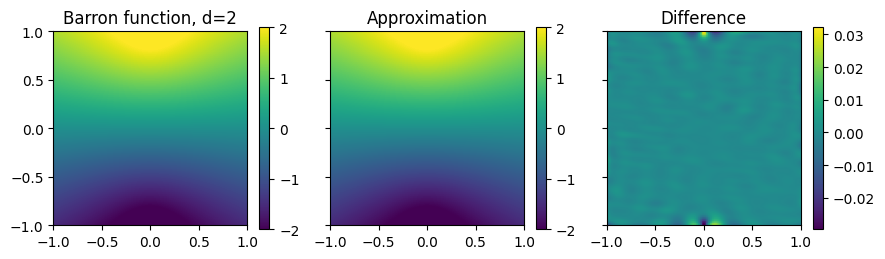

In [4]:
x_space = np.linspace(xlim[0], xlim[1], 100)
xx, yy = np.meshgrid(x_space, x_space)
xy = np.column_stack([xx.ravel(), yy.ravel()])
xy0 = np.column_stack([xx.ravel()*0, yy.ravel()])
vlim = [-2, 2]

model_prediction = model(xy)

fig, ax = plt.subplots(1, 3, figsize=(9, 2.5), sharex=True, sharey=True)
ax0 = ax[0].imshow(barron_e(xy, n_dim=n_dim).reshape(xx.shape), extent=xlim*2, vmin=vlim[0], vmax=vlim[1])
ax1 = ax[1].imshow(model_prediction.reshape(xx.shape), extent=xlim*2, vmin=vlim[0], vmax=vlim[1])
ax_error = ax[2].imshow((barron_e(xy, n_dim=n_dim) - model_prediction).reshape(xx.shape), extent=xlim*2)
fig.colorbar(ax0)
fig.colorbar(ax1)
fig.colorbar(ax_error)

ax[0].set_title('Barron function, d=2')
ax[1].set_title('Approximation')
ax[2].set_title('Difference')

fig.tight_layout()